# Curse of dimensionality

Jab features (columns) bahut zyada ho jaate hain data mein, tab machine learning model confuse ho jata hai aur data bahut sparse (khali-khali) ho jata hai. Is problem ko Curse of Dimensionality bolte hain.

** Dimensions badhte hi data points ek dusre se bahut door ho jaate hain. **

Isliye algorithms jaise:

KNN

K-Means

Distance based models

achha kaam nahi karte high dimensions mein.

# example

Socho tumhe kisi person ko describe karna hai:

Feature	        Value

Height	        170

Weight	        65

Age	            25

Yeh 3 features = easy

But agar 100 features ho:

Height

Weight

Age

Shoe size

Favorite color

Mobile brand

Internet speed

Typing speed

Walking speed

etc...

Ab similar person dhoondhna bahut mushkil ho jayega → Curse of Dimensionality

# What are the Problem ?

High dimensions → Problems:

* Overfitting

* Model slow ho jata hai

* Distance meaningless ho jati hai

* More data chahiye

* Visualization impossible


# Solution kya hai?

Isko solve karne ke liye use karte hain:

Method	             Use

PCA	                 Dimensionality kam

Feature Selection	   Important features select

Lasso Regression	   Feature reduce

Tree models	         High dimension handle

# PCA (Principal Component Analysis)

# Problem pehle samjho

Maan lo tumhare data mein 100 features hain:

Height

Weight

Age

Salary

Experience

Marks

etc...

But sab features important nahi hote, aur kuch features ek jaise info dete hain.

# Example:

Height aur Weight → body size

Salary aur Experience → career growth

Toh duplicate type information ho rahi hai.

#  PCA kya karta hai?

PCA 100 features ko kam karke 2–3 new features bana deta hai

Aur un new features mein maximum information hota hai.



# Real Life Example

Height	         Weight	               Age

170	             65	                    20

180	             75	                    22

160	             55	                    19


Height & Weight similar info de rahe hain

PCA in dono ko combine karke ek new feature bana dega:

PC1 = Body Size

PC2 = Age type info

Ab 3 columns → 2 columns

But information almost same.

# Simple Visualization

Original features → PCA → New features

Height \
        → PC1 (Most important info)
Weight /

Age --------→ PC2 (Second important info)

# PCA kyun use karte hain?
Problem	     ------          PCA Solution

Too many columns	  --     Reduce columns

Overfitting	      --        Reduce

Visualization	    --         2D/3D mein plot

Model slow	   --            Fast

Curse of dimensionality	 ---     Solve

# Why variance is important in PCA?

“Jis direction me variance zyada hota hai, us direction me data zyada spread hota hai, aur jahan data zyada spread hota hai wahan information zyada hoti hai. Isliye PCA maximum variance wali direction choose karta hai.”

# Variance : “Variance batata hai data kitna spread (faila hua) hai.”

# Formula

Variance=1/n∑(x-mean)^2



# Agar variance important hai, to PCA me covariance ki zarurat kyu padti hai?

variance sirf ek feature ka spread batata hai, lekin PCA ko ye bhi samajhna hota hai ki features ek dusre ke saath kaise change ho rahe hain, isliye covariance use hota hai.”

# **CODE**

In [1]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)


In [2]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()


In [3]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])


In [4]:

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [5]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [6]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [7]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

Populating the interactive namespace from numpy and matplotlib


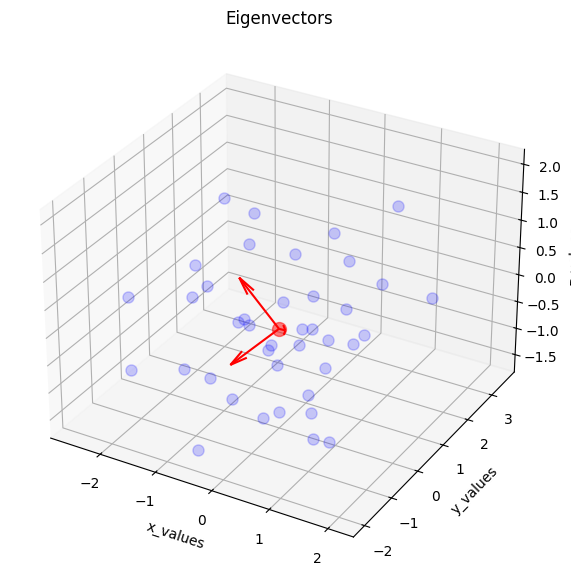

In [8]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d

# Calculate the mean of the features for the starting point of the arrows
mean_feature1 = df['feature1'].mean()
mean_feature2 = df['feature2'].mean()
mean_feature3 = df['feature3'].mean()

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([mean_feature1], [mean_feature2], [mean_feature3], 'o', markersize=10, color='red', alpha=0.5)

# Plot eigenvectors using ax.quiver
for v in eigen_vectors.T:
    ax.quiver(mean_feature1, mean_feature2, mean_feature3, v[0], v[1], v[2], length=1, color='r', arrow_length_ratio=0.3)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()


In [9]:
pc = eigen_vectors[0:2]
pc


array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [10]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [11]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

# TASK

 How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.
 Note : Use KNN for Classification.


In [12]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.head(1)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


In [ ]:
# Your code here

In [13]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [14]:
# Checking for Nan Values
wine.isna().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [15]:
# Checking for duplicated data
wine.duplicated().sum()

np.int64(1168)

In [16]:
# We need to remove duplicated rows and missing value rows
import pandas as pd

# Load the Wine Quality dataset
wine_data = pd.read_csv(wine_data_path)
print("Wine Data Shape :", wine_data.shape)
# Drop rows with missing values
wine_data = wine_data.dropna()

# Dropping Duplicates rows
wine_data.drop_duplicates(inplace=True)
print("Wine Data Shape (After Dropping-) :", wine_data.shape)


Wine Data Shape : (6497, 13)
Wine Data Shape (After Dropping-) : (5295, 13)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# Separate features (physicochemical properties) and target variable (type)
X = wine_data.drop('type', axis=1)
y = wine_data['type']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a K-Nearest Neighbors (KNN) classifier without PCA
knn_no_pca = KNeighborsClassifier(n_neighbors=5)
knn_no_pca.fit(X_train_scaled, y_train)

# Predict the wine type on the testing set without PCA
y_pred_no_pca = knn_no_pca.predict(X_test_scaled)

# Evaluate the classification accuracy without PCA
accuracy_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("KNN having features -", X_train_scaled.shape[1])
print("Classification Accuracy without PCA: {:.2f}%".format(accuracy_no_pca * 100))


KNN having features - 12
Classification Accuracy without PCA: 99.34%


In [18]:
# Apply PCA on the standardized features
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a K-Nearest Neighbors (KNN) classifier with PCA
knn_with_pca = KNeighborsClassifier(n_neighbors=5)
knn_with_pca.fit(X_train_pca, y_train)

# Predict the wine type on the testing set with PCA
y_pred_pca = knn_with_pca.predict(X_test_pca)

# Evaluate the classification accuracy with PCA
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print("KNN having features -", X_train_pca.shape[1])
print("Classification Accuracy with PCA: {:.2f}%".format(accuracy_pca * 100))

KNN having features - 5
Classification Accuracy with PCA: 98.87%
